# Ensemble Methods

## Overview

This notebook demonstrates the public classifier builders in `ensemble_methods` using a synthetic binary classification dataset.
- The notebook loads and processes a reproducible feature table with informative, redundant, and noise columns.
- It builds bagging, random forest, and boosting classifiers from the source module.
- It evaluates the models on a held-out test split and visualizes model metrics and tree-based feature importance.

In [1]:
from pathlib import Path
import sys

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
sys.path.insert(0, str(root))

In [2]:
from src.feature_analysis.ensemble_methods import (
    build_bagging_classifier,
    build_boosting_classifier,
    build_random_forest_classifier,
)
from src.feature_analysis.feature_importance import get_test_data

## Load And Split Classification Data

This section creates the same kind of synthetic data used by the feature-importance module.
- Informative columns start with `I_`, redundant columns with `R_`, and noise columns with `N_`.
- The split is stratified so each classifier sees comparable class balance in train and test sets.
- Sample weights are passed into each estimator fit to exercise the weighted fitting path.

In [3]:
trnsX, cont = get_test_data(
    n_features=12,
    n_informative=4,
    n_redundant=3,
    n_samples=360,
    random_state=21,
)
y = cont["bin"]
sample_weight = cont["w"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    trnsX,
    y,
    sample_weight,
    test_size=0.30,
    shuffle=True,
    stratify=y,
    random_state=21,
)

pd.Series(
    {
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "num_features": trnsX.shape[1],
        "train_positive_rate": y_train.mean(),
        "test_positive_rate": y_test.mean(),
    }
)

train_rows             252.000000
test_rows              108.000000
num_features            12.000000
train_positive_rate      0.496032
test_positive_rate       0.490741
dtype: float64

### Interpretation

The ensemble examples use a balanced, reproducible classification problem rather than relying on external market data.
- The current split contains `252` training rows and `108` test rows across `12` features.
- Stratification keeps the positive-label rate close in both splits, so the metric comparison is not driven by a class-ratio mismatch.
- The feature names preserve the known synthetic structure, which makes later importance plots easier to interpret.

## Build And Fit Ensemble Classifiers

This section executes all three builder functions from `ensemble_methods`.
- Bagging wraps entropy decision trees and samples rows/features across base estimators.
- Random forest adds random feature selection at each split with balanced bootstrap classes.
- AdaBoost fits a sequence of shallow trees that focus later rounds on harder observations.

In [4]:
models = {
    "Bagging": build_bagging_classifier(
        n_estimators=50,
        max_samples=0.75,
        n_jobs=1,
        random_state=21,
    ),
    "Random Forest": build_random_forest_classifier(
        n_estimators=50,
        n_jobs=1,
        random_state=21,
    ),
    "AdaBoost": build_boosting_classifier(
        n_estimators=50,
        learning_rate=0.5,
        max_depth=1,
        random_state=21,
    ),
}

metric_rows = []
fitted_models = {}
for name, clf in models.items():
    fit = clf.fit(X_train, y_train, sample_weight=w_train.values)
    pred = fit.predict(X_test)
    fitted_models[name] = fit
    metric_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "train_score": fit.score(X_train, y_train),
            "test_score": fit.score(X_test, y_test),
        }
    )

metrics = pd.DataFrame(metric_rows).set_index("model")
metrics

,accuracy,f1,train_score,test_score
model,,,,
Bagging,0.759259,0.763636,0.988095,0.759259
Random Forest,0.805556,0.807339,1.000000,0.805556
AdaBoost,0.777778,0.777778,0.928571,0.777778


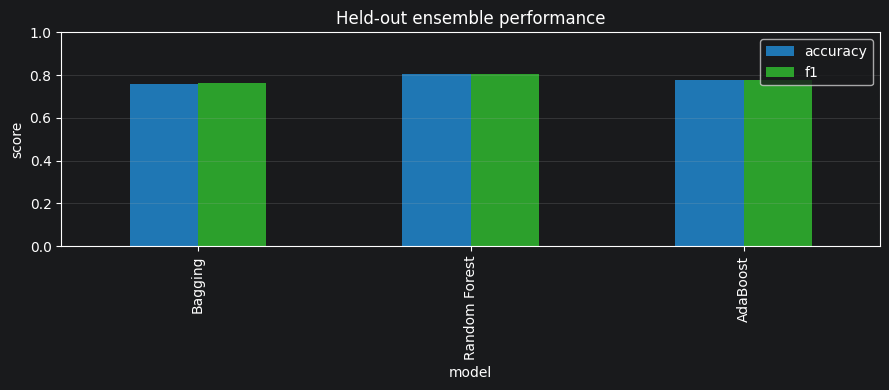

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
metrics[["accuracy", "f1"]].plot(kind="bar", ax=ax, color=["tab:blue", "tab:green"])
ax.set_title("Held-out ensemble performance")
ax.set_xlabel("model")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

### Interpretation

All three builders return fitted classifiers that can consume sample weights and produce standard predictions.
- Random Forest is strongest on this run with accuracy `0.8056` and F1 `0.8073`.
- AdaBoost follows at accuracy `0.7778` and F1 `0.7778`, while Bagging scores accuracy `0.7593` and F1 `0.7636`.
- The spread is modest, which is expected because all three methods use decision-tree base learners on the same synthetic signal.

## Inspect Tree-Based Feature Signals

This section visualizes feature importance for the fitted random forest.
- The feature names reveal whether the model concentrates on informative/redundant columns rather than pure noise.
- The plot is a diagnostic view, not a replacement for the more formal feature-importance notebook.

In [6]:
rf_importance = pd.Series(
    fitted_models["Random Forest"].feature_importances_,
    index=trnsX.columns,
    name="importance",
).sort_values(ascending=False)

rf_importance.head(8)

I_0    0.229305
R_1    0.146609
I_1    0.104309
R_2    0.099124
R_0    0.094269
I_2    0.070174
I_3    0.062489
N_2    0.047475
Name: importance, dtype: float64

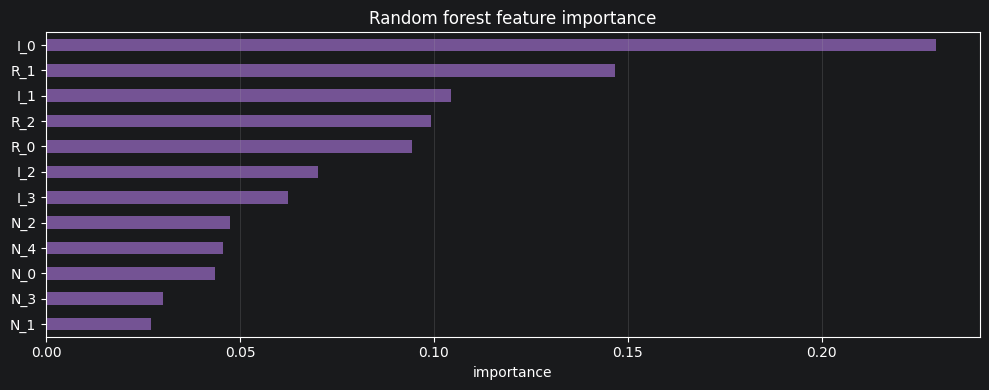

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
rf_importance.sort_values().plot(kind="barh", ax=ax, color="tab:purple", alpha=0.75)
ax.set_title("Random forest feature importance")
ax.set_xlabel("importance")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()

### Interpretation

The random forest puts most of its mass on a small set of signal-bearing columns.
- The top-ranked features are dominated by `I_` and `R_` prefixes, which is consistent with the data generator's informative and redundant feature groups.
- Noise columns are not guaranteed to receive zero importance, but they should usually be less concentrated at the top than true signal columns.
- This quick view confirms the ensemble is learning structure from the feature table rather than only matching class frequency.